# 이동평균과 시계열 트렌드 분석

- `rolling()`으로 이동평균(moving average)을 계산해 데이터의 잔물결(noise)을 걷어내고 추세 분석
- 일별 누적 매출(`cumsum()`)을 함께 그려 "하루 단위 변동"과 "누적 추세"를 구분

In [12]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd
import numpy as np

load_dotenv()

USER = os.getenv("USER")
PASSWORD = os.getenv("PASSWORD")
DSN = os.getenv("DSN")

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

In [7]:
with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)

print(f"총 {len(df)}건의 주문 데이터 로드 완료")
print(df)

총 37건의 주문 데이터 로드 완료
    ORDER_ID MENU_NAME CATEGORY  PRICE  RATING REGION ORDER_DATE
0          1       떡볶이       분식   9000     4.5    강남구 2026-08-01
1          2        치킨       치킨  22000     4.8    서초구 2026-08-02
2          3        피자       피자  25000     4.2    강남구 2026-08-03
3          4       짜장면       중식   8000     4.0    송파구 2026-08-04
4          5       마라탕       중식  13000     4.6    강남구 2026-08-05
5          6       돈까스       일식  11000     4.3    서초구 2026-08-06
6          7       탕수육       중식  18000     4.4    송파구 2026-08-07
7          8       떡볶이       분식   8500     4.3    강남구 2026-08-08
8          9        순대       분식   7000     4.1    서초구 2026-08-08
9         10        치킨       치킨  21000     4.7    강남구 2026-08-09
10        11      양념치킨       치킨  23000     4.9    송파구 2026-08-09
11        12      반반치킨       치킨  22000     4.6    서초구 2026-08-10
12        13        피자       피자  24000     4.0    강남구 2026-08-10
13        14    포테이토피자       피자  27000     4.4    송파구 2026-08-11
14   

C:\Users\lkw\AppData\Local\Temp\ipykernel_16312\2852773367.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


In [9]:
daily_sales = df.groupby("ORDER_DATE")["PRICE"].sum().reset_index()
daily_sales.columns = ["ORDER_DATE", "일매출"]

daily_sales["3일이동평균"] = daily_sales["일매출"].rolling(window=3).mean()
daily_sales["누적매출"] = daily_sales["일매출"].cumsum()

daily_sales.head(10)

,ORDER_DATE,일매출,3일이동평균,누적매출
0,2026-08-01,9000,NaN,9000
1,2026-08-02,22000,NaN,31000
2,2026-08-03,25000,18666.666667,56000
3,2026-08-04,8000,18333.333333,64000
4,2026-08-05,13000,15333.333333,77000
5,2026-08-06,11000,10666.666667,88000
6,2026-08-07,18000,14000.000000,106000
7,2026-08-08,15500,14833.333333,121500
8,2026-08-09,44000,25833.333333,165500
9,2026-08-10,46000,35166.666667,211500


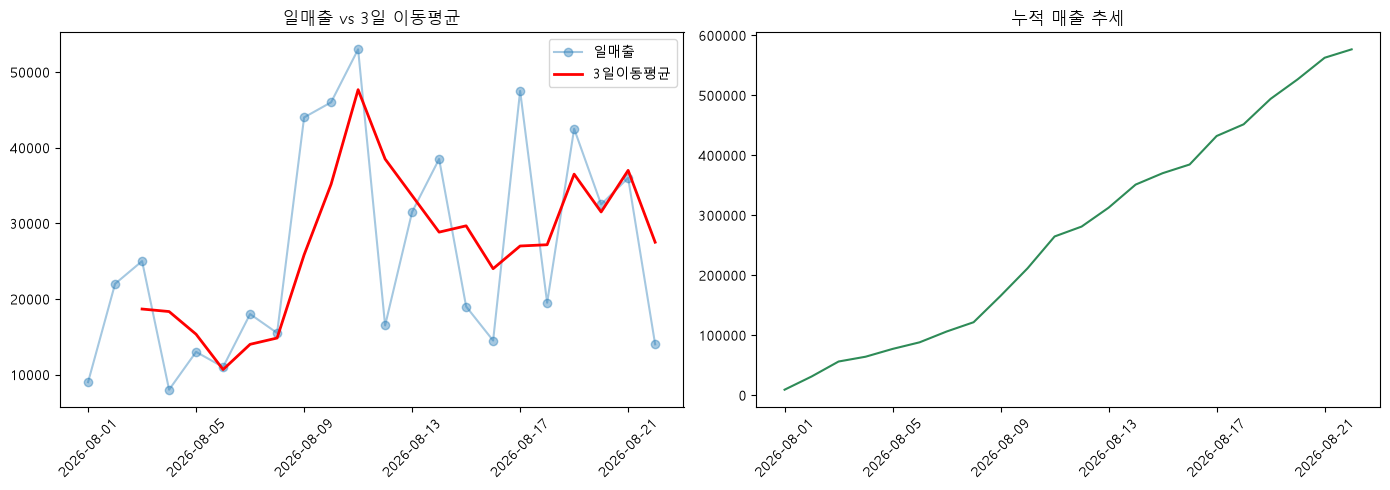

In [18]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].plot(daily_sales["ORDER_DATE"], daily_sales["일매출"], label="일매출", alpha=0.4, marker="o")
axes[0].plot(daily_sales["ORDER_DATE"], daily_sales["3일이동평균"], label="3일이동평균", linewidth=2, color="red")
axes[0].set_title("일매출 vs 3일 이동평균")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(daily_sales["ORDER_DATE"], daily_sales["누적매출"], color="seagreen")
axes[1].set_title("누적 매출 추세")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()